# Penyimpanan Artefak Model dan Metadata Inferensi

Model yang sudah dilatih perlu disimpan bersama metadata yang dibutuhkan saat
inferensi. Menyimpan modelnya saja tidak cukup: bila urutan fitur atau daftar
nilai kategori berbeda antara pelatihan dan inferensi, prediksinya salah tanpa
memunculkan galat apa pun. Kesalahan seperti ini sulit ditemukan karena sistemnya
tetap berjalan normal.

In [1]:
import warnings, sys, json
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import joblib

from sklearn.model_selection import train_test_split
from model.train import load_dataset, FEATURE_ORDER, RANDOM_STATE, _ordinal_encode_for_xgb

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

df = load_dataset()
X, y = df[FEATURE_ORDER], df["stroke"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
art = joblib.load("artifacts/stroke_risk_model.joblib")
model = art["model"]
print("Model dan data siap dimuat.")

Model dan data siap dimuat.


## 1. Isi Artefak

In [2]:
print("ISI ARTEFAK stroke_risk_model.joblib\n")
for k, v in art.items():
    if k == "model":
        print(f"  {k:22s}: {type(v).__name__}")
    elif k == "metrics":
        print(f"  {k:22s}: dict berisi {len(v)} metrik")
    elif isinstance(v, (list, dict)):
        s = str(v)
        print(f"  {k:22s}: {s[:88]}{'…' if len(s) > 88 else ''}")
    else:
        print(f"  {k:22s}: {v}")

from pathlib import Path
ukuran = Path("artifacts/stroke_risk_model.joblib").stat().st_size / 1024
print()
print(f"Ukuran berkas: {ukuran:.0f} KB")

ISI ARTEFAK stroke_risk_model.joblib

  model                 : XGBClassifier
  model_name            : XGBClassifier
  encoding              : ordinal_codes
  feature_order         : ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'is_working', 'gend…
  numeric_features      : ['age', 'avg_glucose_level', 'bmi']
  binary_features       : ['hypertension', 'heart_disease', 'is_working']
  categorical_features  : ['gender', 'residence_type', 'smoking_status']
  category_values       : {'gender': ['Male', 'Female', 'Other'], 'residence_type': ['Urban', 'Rural'], 'smoking_s…
  threshold             : 0.041999999999999926
  high_threshold        : 0.705
  metrics               : dict berisi 15 metrik

Ukuran berkas: 146 KB


## 2. Mengapa Metadata Wajib Disertakan

Uji berikut menunjukkan akibatnya bila urutan fitur tidak dijaga.

In [3]:
Xte_e = _ordinal_encode_for_xgb(X_test)
benar = model.predict_proba(Xte_e)[:, 1]

# Urutan fitur diacak, meniru kesalahan yang mungkin terjadi di sisi server
acak = list(FEATURE_ORDER); acak[0], acak[5] = acak[5], acak[0]
salah = model.predict_proba(Xte_e[acak].rename(
    columns=dict(zip(acak, FEATURE_ORDER)))[FEATURE_ORDER])[:, 1]

beda = np.abs(benar - salah)
print("PENGARUH URUTAN FITUR YANG TERTUKAR")
print(f"  Fitur ditukar   : {FEATURE_ORDER[0]} <-> {FEATURE_ORDER[5]}")
print()
print(f"  Selisih rerata  : {beda.mean():.4f}")
print(f"  Selisih maksimum: {beda.max():.4f}")
print(f"  Sampel berubah keputusan pada ambang {art['threshold']:.3f}: "
      f"{int(((benar >= art['threshold']) != (salah >= art['threshold'])).sum())} dari {len(benar)}")
print()
print("Tidak ada galat yang muncul, tetapi prediksinya berubah. Karena itu")
print("feature_order disimpan di dalam artefak dan dipakai ulang saat inferensi.")

PENGARUH URUTAN FITUR YANG TERTUKAR
  Fitur ditukar   : age <-> is_working

  Selisih rerata  : 0.2492
  Selisih maksimum: 0.7874
  Sampel berubah keputusan pada ambang 0.042: 555 dari 1533

Tidak ada galat yang muncul, tetapi prediksinya berubah. Karena itu
feature_order disimpan di dalam artefak dan dipakai ulang saat inferensi.


## 3. Perbandingan Sebelum dan Sesudah Penukaran

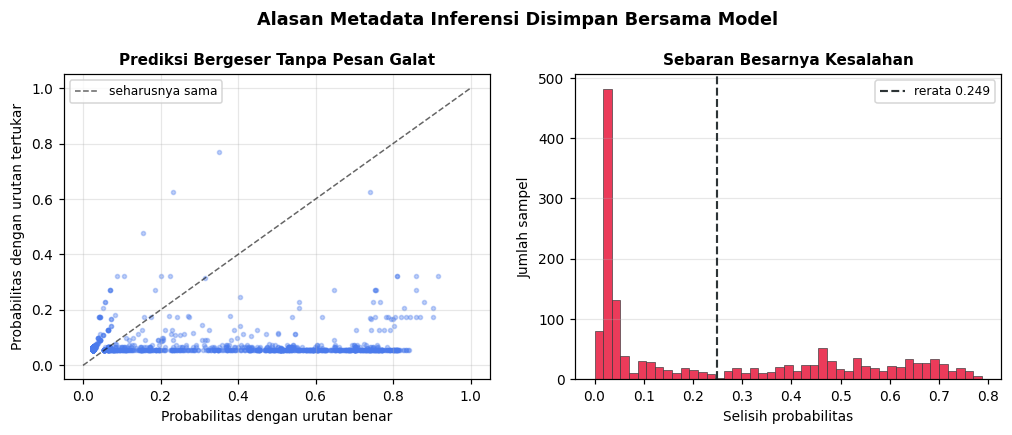

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].scatter(benar, salah, s=7, alpha=.35, color="#4b7bec")
ax[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=.6, label="seharusnya sama")
ax[0].set_xlabel("Probabilitas dengan urutan benar")
ax[0].set_ylabel("Probabilitas dengan urutan tertukar")
ax[0].set_title("Prediksi Bergeser Tanpa Pesan Galat", fontsize=10, fontweight="bold")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].hist(beda, bins=45, color="#eb3b5a", edgecolor="#2d3436", linewidth=.4)
ax[1].axvline(beda.mean(), color="#2d3436", ls="--", lw=1.4,
              label=f"rerata {beda.mean():.3f}")
ax[1].set_xlabel("Selisih probabilitas"); ax[1].set_ylabel("Jumlah sampel")
ax[1].set_title("Sebaran Besarnya Kesalahan", fontsize=10, fontweight="bold")
ax[1].legend(fontsize=8); ax[1].grid(axis="y", alpha=.3)

fig.suptitle("Alasan Metadata Inferensi Disimpan Bersama Model",
             fontsize=11.5, fontweight="bold", y=1.04)
plt.show()

## 4. Kesimpulan

Artefak memuat model beserta urutan sembilan fitur, daftar nilai kategori, jenis
pengodean, dan ambang keputusan. Dengan begitu proses inferensi di server dijamin
memakai susunan yang identik dengan saat pelatihan.

Uji di atas memperlihatkan bahwa menukar dua fitur saja sudah menggeser probabilitas
tanpa memunculkan galat. Inilah alasan metadata tidak boleh dipisahkan dari model.